# KKBox Music Streaming Cohort & Retention Analysis

The competition gives me churn labels, but I wanted to build the retention story from the listening behavior itself.

The question is: **after someone registers and starts listening, how many come back — and what does their first month tell me about whether they'll stick around?**

I'm treating a user as retained in a month if they recorded at least one day of listening activity. Registration month is Month 0, the following month is Month 1, and so on.

The analysis starts with the overall cohort curves, then digs into early engagement, transaction behavior, and acquisition channel.


## What I'm going to look at

1. Build registration cohorts and make sure the timeline makes sense.
2. Measure retention after Month-0 activation.
3. See how first-month listening behavior differs between users who return and users who don't.
4. Check whether that relationship survives after accounting for when in the month someone registered.
5. Look at the smaller group of users I can reliably connect to early transaction data.
6. Compare acquisition channels on activation, engagement, and Month-1 retention.


## 1. Build the cohorts

I'm loading the monthly activity files from the preparation notebook and attaching each user's registration date.

Only registrations from January 2015 through March 2017 are eligible because that's the period where listening activity is observable.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("../data")
MONTHLY_DIR = DATA_DIR / "processed" / "user_month_history"

members = pd.read_csv(
    DATA_DIR / "raw" / "members_v3.csv",
    usecols=[
        "msno",
        "registration_init_time",
        "registered_via",
        "city"
    ]
)

members["registration_date"] = pd.to_datetime(
    members["registration_init_time"].astype(str),
    format="%Y%m%d",
    errors="coerce"
)

members["cohort_month"] = (
    members["registration_date"]
    .dt.to_period("M")
    .astype(str)
)

members.head()

,msno,city,registered_via,registration_init_time,registration_date,cohort_month
0,Rb9UwLQTrxzBVwCB6+bCcSQWZ9JiNLC9dXtM1oEsZA8=,1,11,20110911,2011-09-11,2011-09
1,+tJonkh+O1CA796Fm5X60UMOtB6POHAwPjbTRVl/EuU=,1,7,20110914,2011-09-14,2011-09
2,cV358ssn7a0f7jZOwGNWS07wCKVqxyiImJUX6xcIwKw=,1,11,20110915,2011-09-15,2011-09
3,9bzDeJP6sQodK73K5CBlJ6fgIQzPeLnRl0p5B77XP+g=,1,11,20110915,2011-09-15,2011-09
4,WFLY3s7z4EZsieHCt63XrsdtfTEmJ+2PnnKLH5GY4Tk=,6,9,20110915,2011-09-15,2011-09


In [2]:
monthly_files = sorted(
    MONTHLY_DIR.glob("user_month_*.parquet")
)

print("Monthly activity files:", len(monthly_files))
print("First:", monthly_files[0].name)
print("Last:", monthly_files[-1].name)

Monthly activity files: 27
First: user_month_2015-01.parquet
Last: user_month_2017-03.parquet


In [3]:
activity_parts = []

for file in monthly_files:
    part = pd.read_parquet(
        file,
        columns=[
            "msno",
            "activity_month",
            "active_days",
            "total_secs",
            "daily_unique_songs_sum"
        ]
    )

    activity_parts.append(part)

activity = pd.concat(
    activity_parts,
    ignore_index=True
)

print("User-month activity rows:", f"{len(activity):,}")
print("Unique active users:", f"{activity['msno'].nunique():,}")

activity.head()

User-month activity rows: 27,862,865
Unique active users: 5,339,422


,msno,activity_month,active_days,total_secs,daily_unique_songs_sum
0,+++IZseRRiQS9aaSkH6cMYU6bGDcxUieAi/tH67sC5s=,2015-01,21,446494.575,1472
1,+++l/EXNMLTijfLBa8p2TUVVVp2aFGSuUI/h7mLmthw=,2015-01,12,22478.437,137
2,+++rMjxjARDHEx9zEFOpvJEDBDhT1ncn0PEnCx3llA0=,2015-01,5,1719.148,9
3,+++snpr7pmobhLKUgSHTv/mpkqgBT0tQJ0zQj6qKrqc=,2015-01,31,671863.109,1983
4,+++tnuKxIMqc8AGBaCielES3l1wnQ9tz3OwrI0zTL6Y=,2015-01,2,1273.048,5


In [4]:
# no point creating cohorts I can't observe

eligible_members = members[
    (members["registration_date"] >= "2015-01-01") &
    (members["registration_date"] <= "2017-03-31")
].copy()

print("Eligible registered users:", f"{len(eligible_members):,}")

Eligible registered users: 4,293,876


In [5]:

cohort_activity = activity.merge(
    eligible_members[
        ["msno", "registration_date", "cohort_month"]
    ],
    on="msno",
    how="inner"
)

print("Activity rows before cohort join:", f"{len(activity):,}")
print("Eligible cohort activity rows:", f"{len(cohort_activity):,}")
print(
    "Users with eligible cohort activity:",
    f"{cohort_activity['msno'].nunique():,}"
)

cohort_activity.head()

Activity rows before cohort join: 27,862,865
Eligible cohort activity rows: 10,125,894
Users with eligible cohort activity: 3,814,896


,msno,activity_month,active_days,total_secs,daily_unique_songs_sum,registration_date,cohort_month
0,+++tnuKxIMqc8AGBaCielES3l1wnQ9tz3OwrI0zTL6Y=,2015-01,2,1273.048,5,2015-01-05,2015-01
1,++//p4u8bCX0VuvkUly817ttjLSs4NFKHlK3tr+ElLI=,2015-01,2,377.470,3,2015-09-23,2015-09
2,++2Qe2Uw1ATRcxTGYa5GisDYDgm5qkhagxgsfkhB2g8=,2015-01,3,15494.969,68,2015-01-11,2015-01
3,++6jirKNBntOHijpM6rs8WNEptepj0/Ifv9egSiVMV0=,2015-01,4,1557.356,29,2015-01-05,2015-01
4,++CQ1VYBzjEJxVDqxPOlj10bmTl9FfGfzs/Dc9P8X0s=,2015-01,2,938.443,4,2015-01-18,2015-01


In [6]:
# Periods make the month math less annoying

cohort_activity["activity_period"] = pd.PeriodIndex(
    cohort_activity["activity_month"],
    freq="M"
)

cohort_activity["cohort_period"] = pd.PeriodIndex(
    cohort_activity["cohort_month"],
    freq="M"
)

# Month 0 = registration month
# Month 1 = one month after registration
# Month 2 = two months after registration, etc.

cohort_activity["cohort_age"] = (
    (cohort_activity["activity_period"].dt.year -
     cohort_activity["cohort_period"].dt.year) * 12
    +
    (cohort_activity["activity_period"].dt.month -
     cohort_activity["cohort_period"].dt.month)
)

cohort_activity[
    ["msno", "cohort_month", "activity_month", "cohort_age"]
].head(10)

,msno,cohort_month,activity_month,cohort_age
0,+++tnuKxIMqc8AGBaCielES3l1wnQ9tz3OwrI0zTL6Y=,2015-01,2015-01,0
1,++//p4u8bCX0VuvkUly817ttjLSs4NFKHlK3tr+ElLI=,2015-09,2015-01,-8
2,++2Qe2Uw1ATRcxTGYa5GisDYDgm5qkhagxgsfkhB2g8=,2015-01,2015-01,0
3,++6jirKNBntOHijpM6rs8WNEptepj0/Ifv9egSiVMV0=,2015-01,2015-01,0
4,++CQ1VYBzjEJxVDqxPOlj10bmTl9FfGfzs/Dc9P8X0s=,2015-01,2015-01,0
5,++Ds9STitm2Qhz3400zJPT8lk47FmZQbyyfdtXDbuIk=,2015-01,2015-01,0
6,++DsaTvc7MKXDXSDqoE0BlgtcxfpPRCXYiNBfwIg1rk=,2015-01,2015-01,0
7,++FM6zdGj2whewSf10HHTRTeg2/jnxq3NQJKeYmAKwY=,2015-01,2015-01,0
8,++IhMswnX3djKNMk4VTXpPi6b5B735AksKjtZ8b155s=,2015-01,2015-01,0
9,++MyJM/TsXTwNV02OWkgcl8J4Z7u6ve6umqru3M6jqI=,2015-01,2015-01,0


In [7]:
print(cohort_activity["cohort_age"].describe())

print(
    "Activity before registration:",
    (cohort_activity["cohort_age"] < 0).sum()
)

count    1.012589e+07
mean     4.902099e+00
std      5.895631e+00
min     -2.600000e+01
25%      0.000000e+00
50%      2.000000e+00
75%      8.000000e+00
max      2.600000e+01
Name: cohort_age, dtype: float64
Activity before registration: 684


### A small timeline problem

I found 684 activity rows that occur before the user's recorded registration month.

Those rows can't represent post-registration retention, whatever caused the mismatch in the source data. It's tiny relative to the full activity history, so I'm excluding them rather than trying to invent an explanation for them.


In [8]:
# the 684 pre-registration rows can't count toward retention

cohort_activity = cohort_activity[
    cohort_activity["cohort_age"] >= 0
].copy()

print(
    "Post-registration activity rows:",
    f"{len(cohort_activity):,}"
)

print(
    "Users with post-registration activity:",
    f"{cohort_activity['msno'].nunique():,}"
)

print(
    "Remaining negative cohort ages:",
    (cohort_activity["cohort_age"] < 0).sum()
)

Post-registration activity rows: 10,125,210
Users with post-registration activity: 3,814,666
Remaining negative cohort ages: 0


In [9]:
# activation here means they listened at least once in Month 0

month_0_users = cohort_activity.loc[
    cohort_activity["cohort_age"] == 0,
    "msno"
].nunique()

eligible_users = eligible_members["msno"].nunique()

print(
    "Eligible registered users:",
    f"{eligible_users:,}"
)

print(
    "Users active in Month 0:",
    f"{month_0_users:,}"
)

print(
    "Month 0 activation rate:",
    f"{month_0_users / eligible_users:.1%}"
)

Eligible registered users: 4,293,876
Users active in Month 0: 3,606,262
Month 0 activation rate: 84.0%


In [10]:
# quick check for obvious cohort-to-cohort shifts

cohort_population = (
    eligible_members
    .groupby("cohort_month")["msno"]
    .nunique()
    .rename("registered_users")
)

month_0_population = (
    cohort_activity[
        cohort_activity["cohort_age"] == 0
    ]
    .groupby("cohort_month")["msno"]
    .nunique()
    .rename("month_0_active_users")
)

activation_by_cohort = (
    pd.concat(
        [cohort_population, month_0_population],
        axis=1
    )
    .fillna(0)
)

activation_by_cohort["activation_rate"] = (
    activation_by_cohort["month_0_active_users"] /
    activation_by_cohort["registered_users"]
)

activation_by_cohort["activation_rate_pct"] = (
    activation_by_cohort["activation_rate"] * 100
)

activation_by_cohort

,registered_users,month_0_active_users,activation_rate,activation_rate_pct
cohort_month,,,,
2015-01,102290,91276,0.892326,89.232574
2015-02,92790,83204,0.896691,89.669145
2015-03,95388,85457,0.895888,89.588837
2015-04,80934,72439,0.895038,89.503793
2015-05,71404,63714,0.892303,89.230295
2015-06,79167,70338,0.888476,88.847626
2015-07,111526,96920,0.869035,86.903502
2015-08,161470,144907,0.897424,89.742367
2015-09,119370,106084,0.888699,88.869900


In [11]:
# retention starts with the people who actually activated

activated_users = (
    cohort_activity[
        cohort_activity["cohort_age"] == 0
    ][["msno", "cohort_month"]]
    .drop_duplicates()
)

print("Activated users:", f"{len(activated_users):,}")

Activated users: 3,606,262


In [12]:
# from here on, I'm following activated users only

retention_activity = cohort_activity.merge(
    activated_users[["msno"]],
    on="msno",
    how="inner"
)

print(
    "Retention activity rows:",
    f"{len(retention_activity):,}"
)

print(
    "Users in retention population:",
    f"{retention_activity['msno'].nunique():,}"
)

Retention activity rows: 9,284,152
Users in retention population: 3,606,262


In [13]:

retention_counts = (
    retention_activity
    .groupby(
        ["cohort_month", "cohort_age"],
        observed=True
    )["msno"]
    .nunique()
    .reset_index(name="active_users")
)

retention_counts.head(15)

,cohort_month,cohort_age,active_users
0,2015-01,0,91276
1,2015-01,1,37222
2,2015-01,2,22056
3,2015-01,3,18798
4,2015-01,4,16616
5,2015-01,5,15348
6,2015-01,6,12184
7,2015-01,7,11407
8,2015-01,8,10979
9,2015-01,9,10713


In [14]:
# every later month is compared back to Month 0

retention_counts = retention_counts.merge(
    month_0_population.rename("activated_users"),
    on="cohort_month",
    how="left"
)

retention_counts["retention_rate"] = (
    retention_counts["active_users"] /
    retention_counts["activated_users"]
)

retention_counts["retention_rate_pct"] = (
    retention_counts["retention_rate"] * 100
)

retention_counts.head(15)

,cohort_month,cohort_age,active_users,activated_users,retention_rate,retention_rate_pct
0,2015-01,0,91276,91276,1.000000,100.000000
1,2015-01,1,37222,91276,0.407796,40.779613
2,2015-01,2,22056,91276,0.241641,24.164074
3,2015-01,3,18798,91276,0.205947,20.594680
4,2015-01,4,16616,91276,0.182041,18.204128
5,2015-01,5,15348,91276,0.168149,16.814935
6,2015-01,6,12184,91276,0.133485,13.348525
7,2015-01,7,11407,91276,0.124973,12.497261
8,2015-01,8,10979,91276,0.120284,12.028354
9,2015-01,9,10713,91276,0.117369,11.736930


In [15]:

retention_matrix = (
    retention_counts
    .pivot(
        index="cohort_month",
        columns="cohort_age",
        values="retention_rate_pct"
    )
    .sort_index()
)

retention_matrix = retention_matrix[
    [c for c in retention_matrix.columns if 0 <= c <= 12]
]

retention_matrix.round(1)

cohort_age,0,1,2,3,4,5,6,7,8,9,10,11,12
cohort_month,,,,,,,,,,,,,
2015-01,100.0,40.8,24.2,20.6,18.2,16.8,13.3,12.5,12.0,11.7,11.4,11.3,11.2
2015-02,100.0,41.0,25.3,20.6,18.3,14.2,13.0,12.4,11.9,11.6,11.4,11.3,11.2
2015-03,100.0,41.7,24.9,20.7,15.2,14.0,13.4,12.9,12.3,12.1,11.9,11.7,11.6
2015-04,100.0,40.9,25.2,17.2,15.0,14.2,13.7,13.0,12.7,12.4,12.1,12.0,11.7
2015-05,100.0,39.9,20.4,17.3,15.8,15.1,14.5,14.0,13.6,13.3,13.1,12.9,12.7
2015-06,100.0,30.2,14.6,13.3,12.7,12.2,11.9,11.7,11.2,11.0,10.7,10.6,10.6
2015-07,100.0,30.0,18.3,17.3,16.6,16.2,16.0,15.5,15.3,15.0,14.9,14.9,14.8
2015-08,100.0,28.9,16.9,15.7,15.0,14.8,14.5,14.2,13.8,13.7,13.6,13.6,13.3
2015-09,100.0,32.8,19.5,18.2,17.6,17.0,16.7,16.2,15.8,15.6,15.5,15.3,15.3


## 2. What does retention actually look like?

The denominator here is **users who were active in Month 0**, not everyone who registered. That means Month 0 is 100% by definition.

Blank cells are also important: they mean a cohort hadn't reached that age by March 2017. They are not zero retention.


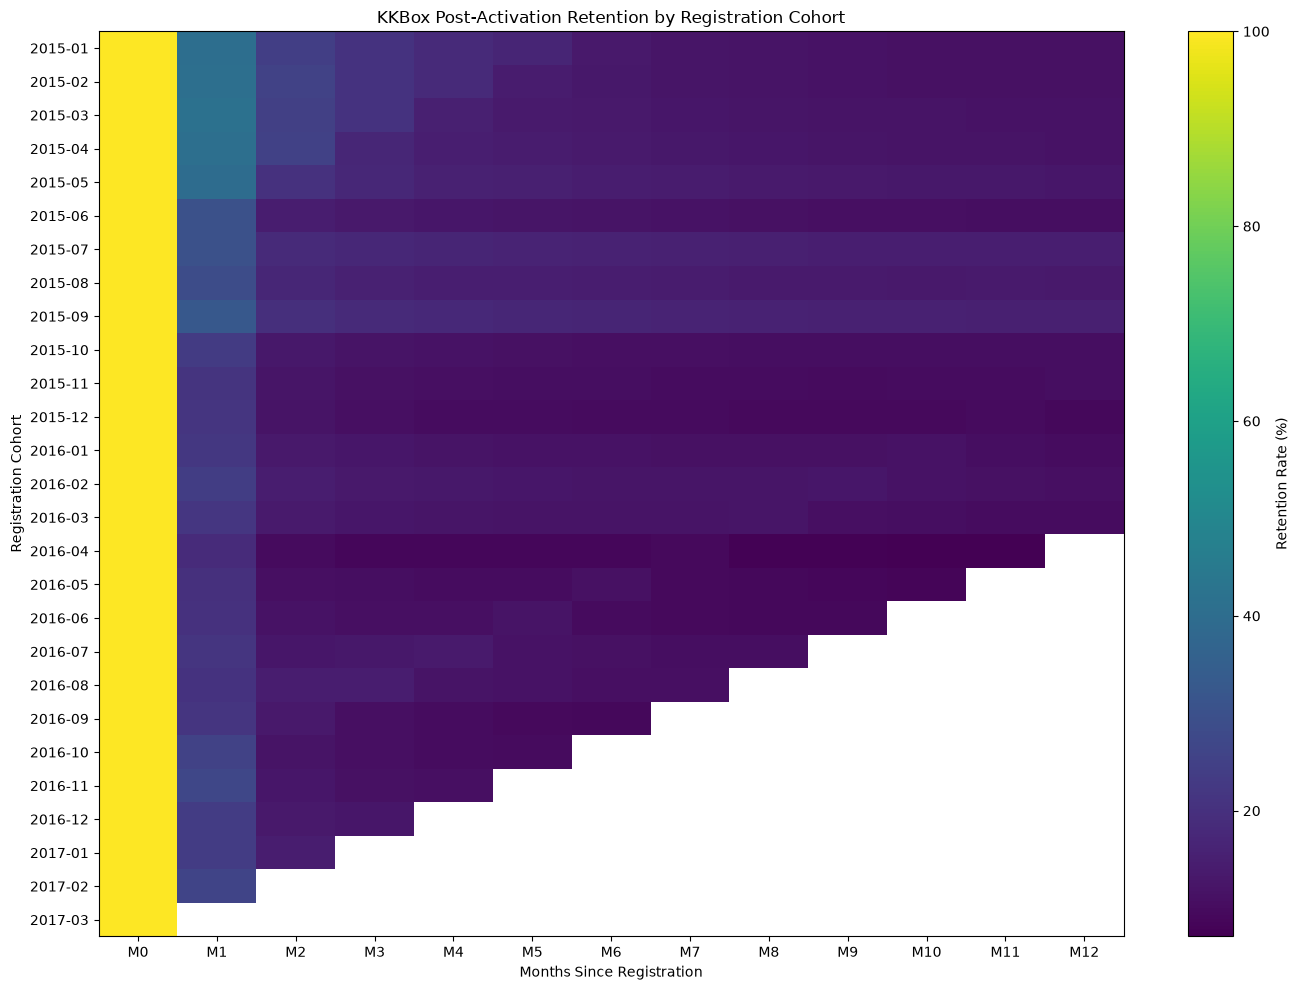

In [16]:

fig, ax = plt.subplots(figsize=(14, 10))

data = retention_matrix.values

heatmap = ax.imshow(
    data,
    aspect="auto",
    interpolation="nearest"
)

ax.set_xticks(range(len(retention_matrix.columns)))
ax.set_xticklabels(
    [f"M{int(c)}" for c in retention_matrix.columns]
)

ax.set_yticks(range(len(retention_matrix.index)))
ax.set_yticklabels(retention_matrix.index)

ax.set_xlabel("Months Since Registration")
ax.set_ylabel("Registration Cohort")
ax.set_title(
    "KKBox Post-Activation Retention by Registration Cohort"
)

cbar = fig.colorbar(heatmap, ax=ax)
cbar.set_label("Retention Rate (%)")

plt.tight_layout()
plt.show()

In [17]:

retention_milestones = []

for month in [1, 3, 6, 12]:
    available = retention_matrix[month].dropna()

    retention_milestones.append({
        "month": f"M{month}",
        "cohorts_observed": len(available),
        "mean_retention_pct": available.mean(),
        "median_retention_pct": available.median(),
        "min_retention_pct": available.min(),
        "max_retention_pct": available.max()
    })

retention_milestones = pd.DataFrame(retention_milestones)

retention_milestones.round(1)

,month,cohorts_observed,mean_retention_pct,median_retention_pct,min_retention_pct,max_retention_pct
0,M1,26,27.2,23.8,18.5,41.7
1,M3,24,14.1,12.9,8.8,20.7
2,M6,21,12.2,11.9,8.7,16.7
3,M12,15,11.6,11.2,9.1,15.3


In [18]:

weighted_milestones = []

for month in [1, 3, 6, 12]:
    milestone = retention_counts[
        retention_counts["cohort_age"] == month
    ]

    weighted_rate = (
        milestone["active_users"].sum() /
        milestone["activated_users"].sum()
    )

    weighted_milestones.append({
        "month": f"M{month}",
        "eligible_cohorts": milestone["cohort_month"].nunique(),
        "activated_users": milestone["activated_users"].sum(),
        "active_users": milestone["active_users"].sum(),
        "weighted_retention_pct": weighted_rate * 100
    })

weighted_milestones = pd.DataFrame(weighted_milestones)

weighted_milestones.round(1)

,month,eligible_cohorts,activated_users,active_users,weighted_retention_pct
0,M1,26,3515311,891225,25.4
1,M3,24,3274803,435826,13.3
2,M6,21,2870322,337586,11.8
3,M12,15,1961792,220366,11.2


## 3. What was different about the people who came back?

The cohort table makes one thing obvious: the biggest drop happens immediately after activation.

So I'm looking backward from Month 1. Were the people who returned already behaving differently during their registration month?

This is observational data, so I'm treating these as signals and associations — not evidence that forcing someone to listen more would cause them to retain.


In [19]:

m1_eligible = retention_activity[
    retention_activity["cohort_month"] <= "2017-02"
].copy()


month_0_behavior = (
    m1_eligible[
        m1_eligible["cohort_age"] == 0
    ][
        [
            "msno",
            "cohort_month",
            "active_days",
            "total_secs",
            "daily_unique_songs_sum"
        ]
    ]
    .copy()
)

print("M1-eligible activated users:", f"{len(month_0_behavior):,}")

M1-eligible activated users: 3,515,311


In [20]:

m1_returners = set(
    m1_eligible.loc[
        m1_eligible["cohort_age"] == 1,
        "msno"
    ]
)

month_0_behavior["retained_m1"] = (
    month_0_behavior["msno"].isin(m1_returners)
)

print(
    month_0_behavior["retained_m1"]
    .value_counts()
)

print()

print(
    month_0_behavior["retained_m1"]
    .value_counts(normalize=True)
)

retained_m1
False    2624086
True      891225
Name: count, dtype: int64

retained_m1
False    0.746473
True     0.253527
Name: proportion, dtype: float64


In [21]:

behavior_summary = (
    month_0_behavior
    .groupby("retained_m1")
    .agg(
        users=("msno", "nunique"),
        median_active_days=("active_days", "median"),
        mean_active_days=("active_days", "mean"),
        median_total_secs=("total_secs", "median"),
        mean_total_secs=("total_secs", "mean"),
        median_daily_unique_songs_sum=(
            "daily_unique_songs_sum",
            "median"
        )
    )
)

behavior_summary

,users,median_active_days,mean_active_days,median_total_secs,mean_total_secs,median_daily_unique_songs_sum
retained_m1,,,,,,
False,2624086,2.0,2.329414,2598.781,-1.651998e+11,16.0
True,891225,4.0,6.582426,13922.240,-5.536766e+12,69.0


In [22]:
# this is where the impossible listening-time values first showed up

print("Negative total_secs rows:",
      (month_0_behavior["total_secs"] < 0).sum())

print("Zero total_secs rows:",
      (month_0_behavior["total_secs"] == 0).sum())

print()

print(month_0_behavior["total_secs"].describe())

Negative total_secs rows: 418
Zero total_secs rows: 0

count    3.515311e+06
mean    -1.527035e+12
std      1.758559e+14
min     -8.301035e+16
25%      7.417330e+02
50%      3.871561e+03
75%      1.476110e+04
max      1.938948e+08
Name: total_secs, dtype: float64


In [23]:
# checking how bad the bad values actually are

month_0_behavior.nsmallest(
    10,
    "total_secs"
)[
    ["msno", "cohort_month", "active_days", "total_secs"]
]

,msno,cohort_month,active_days,total_secs
1293361,F1Qf+rJwHsrE/IkzlcwQ2h4oCuJ3bes5OhBo4KR3rVU=,2015-09,19,-8.301035e+16
826508,39YAd9xfNzNBlBQaOVdIxJ1jykrsNOgAYNffTSfNRWw=,2015-07,30,-8.301035e+16
1128815,YMC/QtRMGQsfgtYArL6fBX31uOy95C2vVtPSj9LyuJo=,2015-08,29,-8.301035e+16
1024672,6bopkbjpuICJNh+XXxn6GAlCJAnHSNhtsgrGRU/jCWg=,2015-08,14,-6.456360e+16
703306,JBAm49CR79L0H0ZszXCfy797BdFAtR7PdMvq+hQgxIM=,2015-06,26,-6.456360e+16
984939,xJcmM9XhdjPUBk1iVZWDp3e8sqI6uT10FCyqRP5oyuA=,2015-07,18,-5.534023e+16
866783,HT/SSa12F9etZhX0JYeNvRpNgJfdnI+ZT4Ogh2VBACc=,2015-07,22,-5.534023e+16
1349243,Uj5H0ZAVfD4XMlTh0ZGzH2Sgz6HoRODRaf1k8Gxdg4U=,2015-09,11,-4.611686e+16
827619,3YyE02YPPi2S4dUUw4hQzz0Bt4Q/jSGXc6gLdIlCIiQ=,2015-07,28,-4.611686e+16
800772,vbc0K9bJ+XK2Woa8Xj3bMRfRe6Deie8AjPji3CdCD68=,2015-06,11,-3.689349e+16


In [24]:
month_0_behavior.nlargest(
    10,
    "total_secs"
)[
    ["msno", "cohort_month", "active_days", "total_secs"]
]

,msno,cohort_month,active_days,total_secs
3627818,eaJlt1v3jUECfcRT+wJF7a4UbfKf/6KloHxal6wmU54=,2016-03,2,1.938948e+08
1082877,M7+l+kE04WcczC6yfxAxpXMnhIXE0N8ioZVtNP2ug1E=,2015-08,3,1.273055e+08
2553046,+rZtKQ5r7BlPispdxbiF1lC1/l2J2CYZ0N1mKp6wOWs=,2016-01,3,1.214361e+08
2322484,NPwQldPV7/UNm+grtWbzuzgtfxQ2GVJrdN2dyizYs6k=,2015-12,12,1.038054e+08
96409,0kEmi3GQCJMY1FVHZ8EWcskwPXLfgnaOTEyXQNcBsao=,2015-02,24,9.603996e+07
473061,nkMxDsURFt/FohLplH496PlhctK6DatdoaQLtoo0pn8=,2015-04,5,9.402475e+07
3435587,9zCflrvboYHgJqkmLEX4IJQq1gcZFFHHXW4r9X5bCuA=,2016-03,6,6.854869e+07
2358012,TVnYPxDP45bSLLGkb99PcQyY+VVntMqNLuN/wgx5GIE=,2015-12,4,5.484428e+07
2387488,YZjQ4H59tM9Y3wUoSGfi6hioOJodwodvyj43pmrR3SQ=,2015-12,1,3.133618e+07
1064481,HELko1gdO+Ytm3dWiOc0gVYfavUELXvwYPaCkQ+gfzM=,2015-08,3,2.742160e+07


In [25]:
print(
    "Negative total_secs in full activity table:",
    (activity["total_secs"] < 0).sum()
)

print(
    "Minimum total_secs:",
    activity["total_secs"].min()
)

print(
    "Maximum total_secs:",
    activity["total_secs"].max()
)

Negative total_secs in full activity table: 42346
Minimum total_secs: -2.398076729572454e+17
Maximum total_secs: 9223372037135596.0


### The listening-time numbers have a problem

This comparison exposed something I didn't expect: some aggregated `total_secs` values are negative, and others are physically impossible given the number of active days.

Before using listening duration as an engagement measure, I need to separate those bad values from the rest of the user-month record.


In [26]:
# this gives me a hard physical ceiling for total_secs

seconds_per_day = 24 * 60 * 60

activity["max_possible_secs"] = (
    activity["active_days"] * seconds_per_day
)

# negative or literally impossible = bad duration value

invalid_total_secs = (
    (activity["total_secs"] < 0) |
    (activity["total_secs"] > activity["max_possible_secs"])
)

print(
    "Invalid listening-time rows:",
    f"{invalid_total_secs.sum():,}"
)

print(
    "Share of activity rows:",
    f"{invalid_total_secs.mean():.4%}"
)

print()

print(
    activity.loc[
        invalid_total_secs,
        ["active_days", "total_secs", "max_possible_secs"]
    ].head(10)
)

Invalid listening-time rows: 46,671
Share of activity rows: 0.1675%

       active_days   total_secs  max_possible_secs
259              2   547377.847             172800
6460            16  1663700.888            1382400
6944            19  2149820.072            1641600
12178            5  9792942.253             432000
13397           31  3836654.491            2678400
14578            5   535189.305             432000
16648           26  3419634.346            2246400
19732           17  1937513.378            1468800
21631           18  2154450.116            1555200
21735            1   155735.664              86400


### I'm cleaning the field, not deleting the users

There are 46,671 user-month rows with invalid listening time, or about 0.17% of the activity table.

Because the problem is specific to `total_secs`, I'm setting only those impossible values to missing. The active-day and song-count information on the same rows is still useful, and dropping the entire user-month would throw that away.


In [28]:
# only blank the bad duration; the rest of the row is still useful

activity.loc[
    invalid_total_secs,
    "total_secs"
] = np.nan

negative_remaining = (
    activity["total_secs"] < 0
).sum()

above_max_remaining = (
    activity["total_secs"] >
    activity["max_possible_secs"]
).sum()

missing_total_secs = (
    activity["total_secs"].isna().sum()
)

print(
    "Missing total_secs after cleaning:",
    f"{missing_total_secs:,}"
)

print(
    "Negative total_secs remaining:",
    f"{negative_remaining:,}"
)

print(
    "Values above physical maximum remaining:",
    f"{above_max_remaining:,}"
)

Missing total_secs after cleaning: 46,671
Negative total_secs remaining: 0
Values above physical maximum remaining: 0


In [29]:

clean_total_secs = (
    activity[
        ["msno", "activity_month", "total_secs"]
    ]
    .rename(columns={"activity_month": "cohort_month"})
)

month_0_behavior = (
    month_0_behavior
    .drop(columns="total_secs")
    .merge(
        clean_total_secs,
        on=["msno", "cohort_month"],
        how="left"
    )
)

print("Month-0 users:", f"{len(month_0_behavior):,}")
print(
    "Missing cleaned listening times:",
    f"{month_0_behavior['total_secs'].isna().sum():,}"
)

Month-0 users: 3,515,311
Missing cleaned listening times: 603


In [30]:

behavior_summary = (
    month_0_behavior
    .groupby("retained_m1")
    .agg(
        users=("msno", "nunique"),
        median_active_days=("active_days", "median"),
        mean_active_days=("active_days", "mean"),
        median_total_secs=("total_secs", "median"),
        mean_total_secs=("total_secs", "mean"),
        median_daily_unique_songs_sum=(
            "daily_unique_songs_sum",
            "median"
        )
    )
)

behavior_summary

,users,median_active_days,mean_active_days,median_total_secs,mean_total_secs,median_daily_unique_songs_sum
retained_m1,,,,,,
False,2624086,2.0,2.329414,2598.604,8971.958443,16.0
True,891225,4.0,6.582426,13934.753,46403.277160,69.0


### Retained users were already much more active in Month 0

The difference is pretty large.

Users who returned in Month 1 had a median of **4 active days** during Month 0, versus **2 days** for users who didn't return. Their median cleaned listening time was about **13,935 seconds (3.9 hours)**, compared with **2,599 seconds (43 minutes)** for non-returners. They also accumulated many more daily unique-song counts.

That doesn't tell me *why* they retained, but it gives me a useful early-engagement signal to test more carefully.


## 4. How strong is the early-engagement signal?

Instead of comparing only two averages, I'm grouping users by how many days they were active during Month 0 and calculating Month-1 retention inside each group.

This should make the relationship easier to interpret — but there's one timing issue I need to deal with before taking the raw day counts too seriously.


In [31]:

active_day_bins = [0, 1, 3, 7, 14, 31]

active_day_labels = [
    "1 day",
    "2–3 days",
    "4–7 days",
    "8–14 days",
    "15–31 days"
]

month_0_behavior["active_day_band"] = pd.cut(
    month_0_behavior["active_days"],
    bins=active_day_bins,
    labels=active_day_labels,
    include_lowest=True
)

month_0_behavior[
    ["active_days", "active_day_band"]
].head(10)

,active_days,active_day_band
0,2,2–3 days
1,3,2–3 days
2,4,4–7 days
3,2,2–3 days
4,7,4–7 days
5,7,4–7 days
6,8,8–14 days
7,7,4–7 days
8,2,2–3 days
9,3,2–3 days


In [32]:

retention_by_active_days = (
    month_0_behavior
    .groupby(
        "active_day_band",
        observed=True
    )
    .agg(
        users=("msno", "nunique"),
        retained_users=("retained_m1", "sum"),
        retention_rate=("retained_m1", "mean")
    )
    .reset_index()
)

retention_by_active_days["retention_rate_pct"] = (
    retention_by_active_days["retention_rate"] * 100
)

retention_by_active_days

,active_day_band,users,retained_users,retention_rate,retention_rate_pct
0,1 day,1357730,198912,0.146503,14.650335
1,2–3 days,1154186,222542,0.192813,19.281294
2,4–7 days,672115,188888,0.281035,28.103524
3,8–14 days,203112,156895,0.772456,77.245559
4,15–31 days,128168,123988,0.967387,96.738656


In [33]:

print(
    "Users without an active-day band:",
    month_0_behavior["active_day_band"].isna().sum()
)

print(
    "Total segmented users:",
    f"{retention_by_active_days['users'].sum():,}"
)

Users without an active-day band: 0
Total segmented users: 3,515,311


### Someone who registers on the 29th doesn't get 31 days

Raw Month-0 active days aren't quite fair because users enter the cohort on different dates.

A person who registers on the first of the month has far more chances to be active than someone who registers near the end. I'm checking how much opportunity each user actually had before treating Month-0 activity frequency as an engagement measure.


In [34]:
# exact signup date tells me how much of Month 0 they actually had

month_0_behavior = month_0_behavior.merge(
    eligible_members[
        ["msno", "registration_date"]
    ],
    on="msno",
    how="left"
)


month_0_behavior["days_available_m0"] = (
    month_0_behavior["registration_date"].dt.days_in_month
    - month_0_behavior["registration_date"].dt.day
    + 1
)

month_0_behavior[
    [
        "registration_date",
        "active_days",
        "days_available_m0"
    ]
].head()

,registration_date,active_days,days_available_m0
0,2015-01-05,2,27
1,2015-01-11,3,21
2,2015-01-05,4,27
3,2015-01-18,2,14
4,2015-01-22,7,10


In [35]:
print(
    month_0_behavior["days_available_m0"].describe()
)

print(
    "Active days greater than available days:",
    (
        month_0_behavior["active_days"] >
        month_0_behavior["days_available_m0"]
    ).sum()
)

count    3.515311e+06
mean     1.585147e+01
std      8.692066e+00
min      1.000000e+00
25%      8.000000e+00
50%      1.600000e+01
75%      2.300000e+01
max      3.100000e+01
Name: days_available_m0, dtype: float64
Active days greater than available days: 44


In [36]:

month_0_behavior["m0_active_day_share"] = (
    month_0_behavior["active_days"] /
    month_0_behavior["days_available_m0"]
)

month_0_behavior[
    [
        "active_days",
        "days_available_m0",
        "m0_active_day_share"
    ]
].describe()

,active_days,days_available_m0,m0_active_day_share
count,3.515311e+06,3.515311e+06,3.515311e+06
mean,3.407666e+00,1.585147e+01,2.934504e-01
std,4.087853e+00,8.692066e+00,2.890965e-01
min,1.000000e+00,1.000000e+00,3.225806e-02
25%,1.000000e+00,8.000000e+00,8.000000e-02
50%,2.000000e+00,1.600000e+01,1.666667e-01
75%,4.000000e+00,2.300000e+01,4.000000e-01
max,3.100000e+01,3.100000e+01,1.400000e+01


### Normalize by the days each user actually had

I'm dividing active days by the number of calendar days available from registration through the end of that month.

There are 44 users whose recorded active days exceed the number theoretically available. That's tiny, so I'm capping those normalized shares at 100% rather than letting a handful of source-data oddities create impossible engagement rates.


In [37]:
# only 44 rows go over 100%, so I'm just capping those

month_0_behavior["m0_active_day_share_clean"] = (
    month_0_behavior["m0_active_day_share"]
    .clip(upper=1)
)

print(
    "Users affected by 100% cap:",
    (
        month_0_behavior["m0_active_day_share"] > 1
    ).sum()
)

print(
    month_0_behavior["m0_active_day_share_clean"].describe()
)

Users affected by 100% cap: 44
count    3.515311e+06
mean     2.934391e-01
std      2.889745e-01
min      3.225806e-02
25%      8.000000e-02
50%      1.666667e-01
75%      4.000000e-01
max      1.000000e+00
Name: m0_active_day_share_clean, dtype: float64


In [38]:

share_bins = [0, 0.10, 0.25, 0.50, 0.75, 1.00]

share_labels = [
    "≤10%",
    "11–25%",
    "26–50%",
    "51–75%",
    "76–100%"
]

month_0_behavior["m0_activity_share_band"] = pd.cut(
    month_0_behavior["m0_active_day_share_clean"],
    bins=share_bins,
    labels=share_labels,
    include_lowest=True
)

retention_by_activity_share = (
    month_0_behavior
    .groupby(
        "m0_activity_share_band",
        observed=True
    )
    .agg(
        users=("msno", "nunique"),
        retained_users=("retained_m1", "sum"),
        retention_rate=("retained_m1", "mean")
    )
    .reset_index()
)

retention_by_activity_share["retention_rate_pct"] = (
    retention_by_activity_share["retention_rate"] * 100
)

retention_by_activity_share

,m0_activity_share_band,users,retained_users,retention_rate,retention_rate_pct
0,≤10%,1146412,67488,0.058869,5.886889
1,11–25%,1099280,135610,0.123363,12.336256
2,26–50%,625361,208733,0.333780,33.378001
3,51–75%,248888,160855,0.646295,64.629472
4,76–100%,395370,318539,0.805673,80.567317


In [39]:
print(
    "Users without normalized engagement band:",
    month_0_behavior[
        "m0_activity_share_band"
    ].isna().sum()
)

print(
    "Total segmented users:",
    f"{retention_by_activity_share['users'].sum():,}"
)

Users without normalized engagement band: 0
Total segmented users: 3,515,311


### This relationship is much stronger than I expected

After normalizing for registration timing, Month-1 retention rises almost monotonically with first-month activity:

- active on ≤10% of available days: **5.9%**
- 11–25%: **12.3%**
- 26–50%: **33.4%**
- 51–75%: **64.6%**
- 76–100%: **80.6%**

That's a **74.7 percentage-point gap** between the lowest- and highest-engagement groups.

I still wouldn't call this causal. But as an early signal for identifying users who are much more or less likely to return, it's hard to ignore.


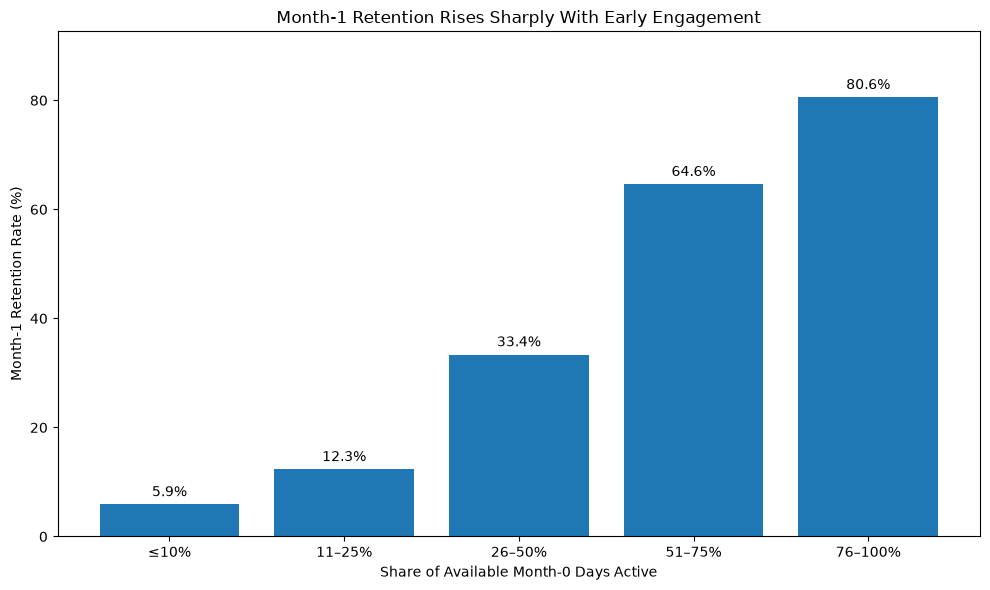

In [40]:

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    retention_by_activity_share["m0_activity_share_band"].astype(str),
    retention_by_activity_share["retention_rate_pct"]
)

ax.set_xlabel("Share of Available Month-0 Days Active")
ax.set_ylabel("Month-1 Retention Rate (%)")
ax.set_title(
    "Month-1 Retention Rises Sharply With Early Engagement"
)

ax.set_ylim(
    0,
    retention_by_activity_share["retention_rate_pct"].max() * 1.15
)

for i, value in enumerate(
    retention_by_activity_share["retention_rate_pct"]
):
    ax.text(
        i,
        value + 1.5,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [41]:

lowest_retention = (
    retention_by_activity_share
    .iloc[0]["retention_rate"]
)

highest_retention = (
    retention_by_activity_share
    .iloc[-1]["retention_rate"]
)

retention_gap_pp = (
    highest_retention - lowest_retention
) * 100

retention_ratio = (
    highest_retention / lowest_retention
)

print(
    "Retention gap:",
    f"{retention_gap_pp:.1f} percentage points"
)

print(
    "Highest vs. lowest retention ratio:",
    f"{retention_ratio:.1f}x"
)

Retention gap: 74.7 percentage points
Highest vs. lowest retention ratio: 13.7x


## 5. Does the first-month signal last?

A strong M1 relationship is useful, but it could disappear quickly.

I'm checking the same Month-0 engagement groups at Months 1, 3, 6, and 12. For each horizon, I only include cohorts old enough to have actually reached that month.


In [42]:

engagement_segments = (
    month_0_behavior[
        [
            "msno",
            "cohort_month",
            "m0_activity_share_band"
        ]
    ]
    .drop_duplicates()
)

engagement_segments.head()

,msno,cohort_month,m0_activity_share_band
0,+++tnuKxIMqc8AGBaCielES3l1wnQ9tz3OwrI0zTL6Y=,2015-01,≤10%
1,++2Qe2Uw1ATRcxTGYa5GisDYDgm5qkhagxgsfkhB2g8=,2015-01,11–25%
2,++6jirKNBntOHijpM6rs8WNEptepj0/Ifv9egSiVMV0=,2015-01,11–25%
3,++CQ1VYBzjEJxVDqxPOlj10bmTl9FfGfzs/Dc9P8X0s=,2015-01,11–25%
4,++Ds9STitm2Qhz3400zJPT8lk47FmZQbyyfdtXDbuIk=,2015-01,51–75%


In [43]:

retention_horizons = [1, 3, 6, 12]

horizon_activity = (
    retention_activity[
        retention_activity["cohort_age"].isin(retention_horizons)
    ]
    [["msno", "cohort_month", "cohort_age"]]
    .drop_duplicates()
)

horizon_activity["retained"] = True

horizon_activity.head()

,msno,cohort_month,cohort_age,retained
91276,+++tnuKxIMqc8AGBaCielES3l1wnQ9tz3OwrI0zTL6Y=,2015-01,1,True
91279,++CQ1VYBzjEJxVDqxPOlj10bmTl9FfGfzs/Dc9P8X0s=,2015-01,1,True
91280,++DsaTvc7MKXDXSDqoE0BlgtcxfpPRCXYiNBfwIg1rk=,2015-01,1,True
91283,++FM6zdGj2whewSf10HHTRTeg2/jnxq3NQJKeYmAKwY=,2015-01,1,True
91289,++TjZ/Rb+O1plkieA+7lQIqtW0nfPGcgUNwySlx49o0=,2015-01,1,True


In [44]:

engagement_segments["cohort_period"] = pd.PeriodIndex(
    engagement_segments["cohort_month"],
    freq="M"
)

last_observed_month = pd.Period("2017-03", freq="M")

long_term_results = []

for horizon in retention_horizons:

    eligible = engagement_segments[
        engagement_segments["cohort_period"] + horizon
        <= last_observed_month
    ].copy()

    retained_users = (
        horizon_activity[
            horizon_activity["cohort_age"] == horizon
        ][["msno", "cohort_month", "retained"]]
    )

    eligible = eligible.merge(
        retained_users,
        on=["msno", "cohort_month"],
        how="left"
    )

    eligible["retained"] = (
        eligible["retained"]
        .fillna(False)
        .astype(bool)
    )

    summary = (
        eligible
        .groupby(
            "m0_activity_share_band",
            observed=True
        )
        .agg(
            users=("msno", "nunique"),
            retained_users=("retained", "sum"),
            retention_rate=("retained", "mean")
        )
        .reset_index()
    )

    summary["month"] = f"M{horizon}"

    long_term_results.append(summary)

retention_by_engagement_horizon = pd.concat(
    long_term_results,
    ignore_index=True
)

retention_by_engagement_horizon[
    "retention_rate_pct"
] = (
    retention_by_engagement_horizon[
        "retention_rate"
    ] * 100
)

retention_by_engagement_horizon

,m0_activity_share_band,users,retained_users,retention_rate,month,retention_rate_pct
0,≤10%,1146412,67488,0.058869,M1,5.886889
1,11–25%,1099280,135610,0.123363,M1,12.336256
2,26–50%,625361,208733,0.333780,M1,33.378001
3,51–75%,248888,160855,0.646295,M1,64.629472
4,76–100%,395370,318539,0.805673,M1,80.567317
5,≤10%,1071170,30416,0.028395,M3,2.839512
6,11–25%,1022667,60132,0.058799,M3,5.879920
7,26–50%,582517,94747,0.162651,M3,16.265105
8,51–75%,231704,91769,0.396061,M3,39.606135
9,76–100%,366745,158762,0.432895,M3,43.289479


In [45]:
retention_engagement_matrix = (
    retention_by_engagement_horizon
    .pivot(
        index="m0_activity_share_band",
        columns="month",
        values="retention_rate_pct"
    )
    .reindex(columns=["M1", "M3", "M6", "M12"])
    .round(1)
)

retention_engagement_matrix

month,M1,M3,M6,M12
m0_activity_share_band,,,,
≤10%,5.9,2.8,2.3,2.3
11–25%,12.3,5.9,5.0,5.0
26–50%,33.4,16.3,14.3,13.2
51–75%,64.6,39.6,36.1,31.6
76–100%,80.6,43.3,39.3,35.0


### The gap is still there a year later

Retention falls for every group over time, but the ordering barely changes.

Users active on ≤10% of their available Month-0 days go from **5.9% retention at M1 to 2.3% at M12**. The 76–100% group goes from **80.6% to 35.0%** over the same horizons.

So first-month engagement isn't only separating immediate returners from non-returners. The differences persist deep into the observable lifecycle.


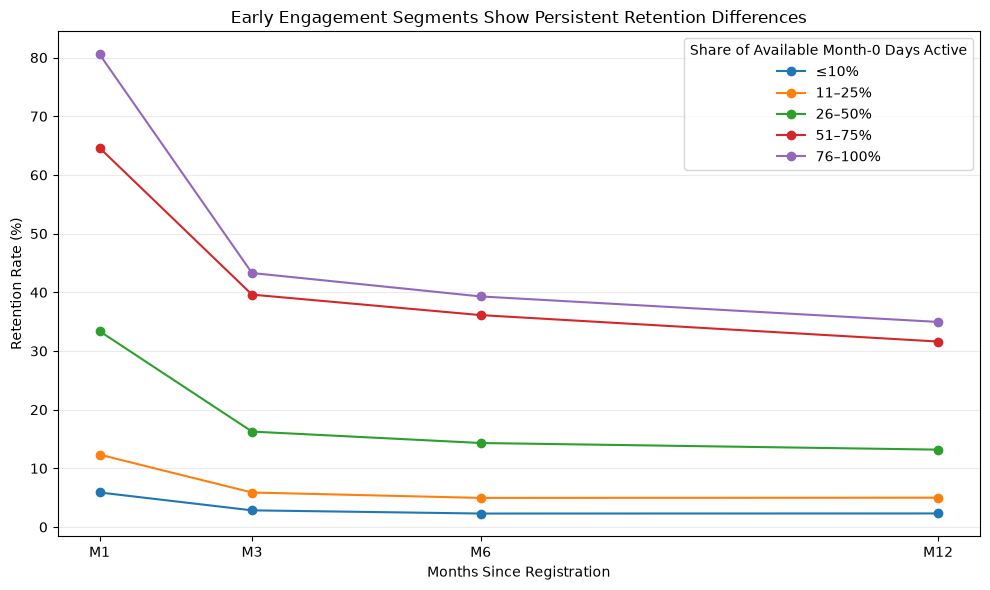

In [46]:

plot_data = (
    retention_by_engagement_horizon
    .copy()
)

plot_data["horizon"] = (
    plot_data["month"]
    .str.replace("M", "", regex=False)
    .astype(int)
)

fig, ax = plt.subplots(figsize=(10, 6))

for band in plot_data["m0_activity_share_band"].cat.categories:

    segment = (
        plot_data[
            plot_data["m0_activity_share_band"] == band
        ]
        .sort_values("horizon")
    )

    ax.plot(
        segment["horizon"],
        segment["retention_rate_pct"],
        marker="o",
        label=str(band)
    )

ax.set_xticks([1, 3, 6, 12])
ax.set_xticklabels(["M1", "M3", "M6", "M12"])

ax.set_xlabel("Months Since Registration")
ax.set_ylabel("Retention Rate (%)")
ax.set_title(
    "Early Engagement Segments Show Persistent Retention Differences"
)

ax.legend(
    title="Share of Available Month-0 Days Active"
)

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()

In [47]:
m12_results = (
    retention_by_engagement_horizon[
        retention_by_engagement_horizon["month"] == "M12"
    ]
    .reset_index(drop=True)
)

m12_low = m12_results.iloc[0]["retention_rate"]
m12_high = m12_results.iloc[-1]["retention_rate"]

m12_gap_pp = (
    m12_high - m12_low
) * 100

m12_ratio = (
    m12_high / m12_low
)

print(
    "M12 retention gap:",
    f"{m12_gap_pp:.1f} percentage points"
)

print(
    "Highest vs. lowest M12 retention ratio:",
    f"{m12_ratio:.1f}x"
)

M12 retention gap: 32.6 percentage points
Highest vs. lowest M12 retention ratio: 15.1x


## 6. What can the transaction data add?

Listening activity tells me whether people came back to use the product. The transaction files give me a narrower look at the subscription side.

I have to be careful here because transaction coverage is incomplete, and a transaction observed months after registration shouldn't be treated like an acquisition attribute. I'm starting by finding each user's earliest transaction on or after registration and checking how close it actually was to signup.


In [51]:

transaction_files = [
    DATA_DIR / "raw" / "transactions.csv",
    DATA_DIR / "raw" / "transactions_v2.csv"
]

transaction_cols = [
    "msno",
    "payment_method_id",
    "payment_plan_days",
    "plan_list_price",
    "actual_amount_paid",
    "is_auto_renew",
    "transaction_date",
    "membership_expire_date",
    "is_cancel"
]

eligible_registration = (
    eligible_members[
        ["msno", "registration_date"]
    ]
    .drop_duplicates("msno")
)

earliest_transaction_parts = []

for filepath in transaction_files:

    print(f"Processing {filepath.name}...")

    for chunk_number, chunk in enumerate(
        pd.read_csv(
            filepath,
            usecols=transaction_cols,
            chunksize=1_000_000
        ),
        start=1
    ):

        chunk["transaction_date"] = pd.to_datetime(
            chunk["transaction_date"].astype(str),
            format="%Y%m%d",
            errors="coerce"
        )

        chunk = chunk.dropna(
            subset=["transaction_date"]
        )

        chunk = chunk.merge(
            eligible_registration,
            on="msno",
            how="inner"
        )

        chunk = chunk[
            chunk["transaction_date"] >=
            chunk["registration_date"]
        ]

        if len(chunk) == 0:
            continue

        chunk = (
            chunk
            .sort_values("transaction_date")
            .drop_duplicates(
                subset="msno",
                keep="first"
            )
        )

        earliest_transaction_parts.append(
            chunk[transaction_cols]
        )

        if chunk_number % 5 == 0:
            print(
                f"{filepath.name}: processed "
                f"{chunk_number:,} million rows"
            )

    print(f"{filepath.name}: complete.")

Processing transactions.csv...
transactions.csv: processed 5 million rows
transactions.csv: processed 10 million rows
transactions.csv: processed 15 million rows
transactions.csv: processed 20 million rows
transactions.csv: complete.
Processing transactions_v2.csv...
transactions_v2.csv: complete.


In [52]:

first_transactions = pd.concat(
    earliest_transaction_parts,
    ignore_index=True
)

print(
    "Partial earliest-transaction rows:",
    f"{len(first_transactions):,}"
)

first_transactions = (
    first_transactions
    .sort_values("transaction_date")
    .drop_duplicates(
        subset="msno",
        keep="first"
    )
    .reset_index(drop=True)
)

print(
    "Users with a post-registration transaction:",
    f"{len(first_transactions):,}"
)

print(
    "Duplicate users:",
    first_transactions["msno"].duplicated().sum()
)

first_transactions.head()

Partial earliest-transaction rows: 4,912,097
Users with a post-registration transaction: 917,769
Duplicate users: 0


,msno,payment_method_id,payment_plan_days,plan_list_price,actual_amount_paid,is_auto_renew,transaction_date,membership_expire_date,is_cancel
0,oNRATgrobS0+RCz+LEUaj+Fq9ckDlt7IexNZFX+g4QI=,38,410,1788,1788,0,2015-01-01,20160216,0
1,pxctiCiLCbLiuBJj79DxSwPj4/jSM4RfQ9UdZxVe54g=,37,31,149,149,1,2015-01-01,20150201,0
2,T3lCuWdkYk9AI/v1pyiXTUZrqYzjAo/eVtQCy7moV/U=,32,195,894,894,0,2015-01-01,20150719,0
3,K9bOBfDlFl9ptC0TfLYi3usb4thIc9I8Yz77oy7VfD4=,41,30,149,0,1,2015-01-01,20150228,0
4,RhCO3OIqA0nDW6NkJHoaAWVdk/1p3Kupj33dVhwWL/A=,41,30,149,149,1,2015-01-01,20150131,0


### First, make sure the transaction is actually "early"

I don't want to accidentally use future information to explain retention.

So before looking at auto-renew or other transaction fields, I'm measuring the gap between registration and each user's first observed post-registration transaction.


In [53]:

first_transactions = first_transactions.merge(
    eligible_members[
        ["msno", "registration_date", "cohort_month"]
    ],
    on="msno",
    how="left"
)

first_transactions["days_from_registration"] = (
    first_transactions["transaction_date"]
    - first_transactions["registration_date"]
).dt.days

print(
    first_transactions["days_from_registration"].describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

print(
    "\nTransactions before registration:",
    (first_transactions["days_from_registration"] < 0).sum()
)

count    917769.000000
mean         63.153088
std         122.627514
min           0.000000
25%           0.000000
50%           1.000000
75%          69.000000
90%         240.000000
95%         344.000000
99%         555.000000
max         817.000000
Name: days_from_registration, dtype: float64

Transactions before registration: 0


In [54]:

timing_summary = pd.DataFrame({
    "window": [
        "Same day",
        "Within 7 days",
        "Within 30 days",
        "Within 60 days",
        "Within 90 days"
    ],
    "users": [
        (first_transactions["days_from_registration"] == 0).sum(),
        (first_transactions["days_from_registration"] <= 7).sum(),
        (first_transactions["days_from_registration"] <= 30).sum(),
        (first_transactions["days_from_registration"] <= 60).sum(),
        (first_transactions["days_from_registration"] <= 90).sum()
    ]
})

timing_summary["share_pct"] = (
    timing_summary["users"] /
    len(first_transactions) * 100
)

timing_summary

,window,users,share_pct
0,Same day,457761,49.877584
1,Within 7 days,570376,62.148100
2,Within 30 days,639517,69.681696
3,Within 60 days,678184,73.894847
4,Within 90 days,711669,77.543369


In [55]:

transaction_coverage = (
    activated_users[["msno"]]
    .merge(
        first_transactions[["msno"]],
        on="msno",
        how="left",
        indicator=True
    )
)

print(
    "Activated users:",
    f"{len(transaction_coverage):,}"
)

print(
    "Activated users with post-registration transaction:",
    f"{(transaction_coverage['_merge'] == 'both').sum():,}"
)

print(
    "Transaction coverage:",
    f"{(transaction_coverage['_merge'] == 'both').mean():.1%}"
)

Activated users: 3,606,262
Activated users with post-registration transaction: 769,215
Transaction coverage: 21.3%


### This is a much smaller subgroup

Only 769,215 of the 3.61 million activated users have a post-registration transaction I can observe, about **21.3%** of the retention population.

And even within that group, timing varies a lot: about half have a transaction on registration day, 62.1% within a week, and 69.7% within 30 days.

I'm restricting the next comparison to transactions observed within 30 days. That makes the acquisition-period interpretation more defensible, but it also means the result applies to this transaction-observed subgroup — not the whole KKBox population.


In [56]:
# 30 days keeps this reasonably close to acquisition

early_transactions = first_transactions[
    first_transactions["days_from_registration"].between(0, 30)
].copy()

early_transaction_users = (
    activated_users[["msno", "cohort_month"]]
    .merge(
        early_transactions[
            [
                "msno",
                "is_auto_renew",
                "payment_plan_days",
                "plan_list_price",
                "actual_amount_paid",
                "is_cancel",
                "days_from_registration"
            ]
        ],
        on="msno",
        how="inner"
    )
)

print(
    "Activated users with transaction within 30 days:",
    f"{len(early_transaction_users):,}"
)

print(
    "Share of activated users:",
    f"{len(early_transaction_users) / len(activated_users):.1%}"
)

print()

print(
    early_transaction_users["is_auto_renew"]
    .value_counts(dropna=False)
)

print()

print(
    early_transaction_users["is_auto_renew"]
    .value_counts(normalize=True, dropna=False)
)

Activated users with transaction within 30 days: 559,142
Share of activated users: 15.5%

is_auto_renew
1    342820
0    216322
Name: count, dtype: int64

is_auto_renew
1    0.613118
0    0.386882
Name: proportion, dtype: float64


In [57]:

auto_renew_analysis = early_transaction_users[
    early_transaction_users["cohort_month"] <= "2017-02"
].copy()

m1_users = (
    retention_activity[
        retention_activity["cohort_age"] == 1
    ]["msno"]
    .drop_duplicates()
)

auto_renew_analysis["retained_m1"] = (
    auto_renew_analysis["msno"].isin(m1_users)
)

auto_renew_retention = (
    auto_renew_analysis
    .groupby("is_auto_renew")
    .agg(
        users=("msno", "nunique"),
        retained_users=("retained_m1", "sum"),
        retention_rate=("retained_m1", "mean")
    )
    .reset_index()
)

auto_renew_retention["retention_rate_pct"] = (
    auto_renew_retention["retention_rate"] * 100
)

auto_renew_retention

,is_auto_renew,users,retained_users,retention_rate,retention_rate_pct
0,0,211298,187631,0.887992,88.799231
1,1,331723,298295,0.899229,89.922918


In [58]:
print(
    "Users in auto-renew M1 analysis:",
    f"{len(auto_renew_analysis):,}"
)

print(
    "Overall M1 retention in transaction subgroup:",
    f"{auto_renew_analysis['retained_m1'].mean():.1%}"
)

print(
    "Overall M1 retention in full eligible activated population:",
    f"{month_0_behavior['retained_m1'].mean():.1%}"
)

Users in auto-renew M1 analysis: 543,021
Overall M1 retention in transaction subgroup: 89.5%
Overall M1 retention in full eligible activated population: 25.4%


### Auto-renew barely separates this subgroup

Among activated users with a transaction within 30 days, 61.3% had auto-renew enabled.

Their Month-1 retention was **89.9%**, compared with **88.8%** for users without auto-renew — only about a 1.1 percentage-point difference.

The more striking number is the subgroup itself: its overall M1 retention is about **89.5%**, versus **25.4%** in the full eligible activated population. That selection difference is much larger than the auto-renew gap, which is why I wouldn't generalize this result beyond users with an early observed transaction.


In [59]:

non_auto_retention = (
    auto_renew_retention
    .loc[
        auto_renew_retention["is_auto_renew"] == 0,
        "retention_rate"
    ]
    .iloc[0]
)

auto_retention = (
    auto_renew_retention
    .loc[
        auto_renew_retention["is_auto_renew"] == 1,
        "retention_rate"
    ]
    .iloc[0]
)

auto_renew_gap_pp = (
    auto_retention - non_auto_retention
) * 100

print(
    "Auto-renew M1 retention gap:",
    f"{auto_renew_gap_pp:.1f} percentage points"
)

Auto-renew M1 retention gap: 1.1 percentage points


## 7. Are the biggest acquisition channels actually the best ones?

Registration volume by itself doesn't tell me whether a channel brings in users who stick.

I'm comparing each `registered_via` code on three things: Month-0 activation, normalized Month-0 engagement, and Month-1 retention among activated users.

The dataset only gives coded channel IDs, so I'm keeping the labels as-is rather than guessing what each channel represents.


In [60]:

channel_population = (
    eligible_members[
        ["msno", "cohort_month", "registered_via"]
    ]
    .drop_duplicates("msno")
    .copy()
)

activated_ids = set(
    activated_users["msno"].unique()
)

channel_population["activated_m0"] = (
    channel_population["msno"].isin(activated_ids)
)

channel_activation = (
    channel_population
    .groupby("registered_via")
    .agg(
        registered_users=("msno", "nunique"),
        activated_users=("activated_m0", "sum"),
        activation_rate=("activated_m0", "mean")
    )
    .reset_index()
)

channel_activation["activation_rate_pct"] = (
    channel_activation["activation_rate"] * 100
)

channel_activation = (
    channel_activation
    .sort_values(
        "registered_users",
        ascending=False
    )
)

channel_activation

,registered_via,registered_users,activated_users,activation_rate,activation_rate_pct
3,4,2791042,2322025,0.831956,83.195631
2,3,603315,527256,0.873932,87.393153
8,9,526869,468503,0.889221,88.922104
6,7,354029,284058,0.802358,80.235800
10,11,5365,0,0.000000,0.000000
11,13,4909,4380,0.892239,89.223875
4,5,3115,0,0.000000,0.000000
14,17,1494,0,0.000000,0.000000
5,6,1213,0,0.000000,0.000000
15,19,974,0,0.000000,0.000000


In [61]:

channel_retention = (
    month_0_behavior
    .merge(
        eligible_members[
            ["msno", "registered_via"]
        ].drop_duplicates("msno"),
        on="msno",
        how="left"
    )
)

channel_retention = channel_retention[
    channel_retention["cohort_month"] <= "2017-02"
].copy()

channel_retention["retained_m1"] = (
    channel_retention["msno"].isin(m1_users)
)

channel_retention_summary = (
    channel_retention
    .groupby("registered_via")
    .agg(
        activated_users=("msno", "nunique"),
        retained_users=("retained_m1", "sum"),
        m1_retention_rate=("retained_m1", "mean"),
        median_m0_activity_share=(
            "m0_active_day_share_clean",
            "median"
        ),
        mean_m0_activity_share=(
            "m0_active_day_share_clean",
            "mean"
        )
    )
    .reset_index()
)

channel_retention_summary["m1_retention_pct"] = (
    channel_retention_summary[
        "m1_retention_rate"
    ] * 100
)

channel_retention_summary[
    "median_m0_activity_share_pct"
] = (
    channel_retention_summary[
        "median_m0_activity_share"
    ] * 100
)

channel_retention_summary[
    "mean_m0_activity_share_pct"
] = (
    channel_retention_summary[
        "mean_m0_activity_share"
    ] * 100
)

channel_retention_summary = (
    channel_retention_summary
    .sort_values(
        "activated_users",
        ascending=False
    )
)

channel_retention_summary

,registered_via,activated_users,retained_users,m1_retention_rate,median_m0_activity_share,mean_m0_activity_share,m1_retention_pct,median_m0_activity_share_pct,mean_m0_activity_share_pct
1,4,2261433,325526,0.143947,0.142857,0.250943,14.394678,14.285714,25.094316
0,3,516002,160893,0.311807,0.222222,0.331093,31.180693,22.222222,33.109270
3,9,458739,157333,0.342968,0.200000,0.340263,34.296844,20.000000,34.026289
2,7,275361,244105,0.886491,0.473684,0.489692,88.649082,47.368421,48.969194
5,13,3737,3366,0.900723,0.629630,0.602354,90.072250,62.962963,60.235432
6,16,33,1,0.030303,0.115385,0.260071,3.030303,11.538462,26.007116
4,10,6,1,0.166667,0.095455,0.111189,16.666667,9.545455,11.118878


In [62]:
channel_summary = (
    channel_activation[
        [
            "registered_via",
            "registered_users",
            "activation_rate_pct"
        ]
    ]
    .merge(
        channel_retention_summary[
            [
                "registered_via",
                "activated_users",
                "median_m0_activity_share_pct",
                "m1_retention_pct"
            ]
        ],
        on="registered_via",
        how="left"
    )
)

channel_summary = (
    channel_summary
    .sort_values(
        "registered_users",
        ascending=False
    )
    .reset_index(drop=True)
)

channel_summary.round({
    "activation_rate_pct": 1,
    "median_m0_activity_share_pct": 1,
    "m1_retention_pct": 1
})

,registered_via,registered_users,activation_rate_pct,activated_users,median_m0_activity_share_pct,m1_retention_pct
0,4,2791042,83.2,2261433.0,14.3,14.4
1,3,603315,87.4,516002.0,22.2,31.2
2,9,526869,88.9,458739.0,20.0,34.3
3,7,354029,80.2,275361.0,47.4,88.6
4,11,5365,0.0,NaN,NaN,NaN
5,13,4909,89.2,3737.0,63.0,90.1
6,5,3115,0.0,NaN,NaN,NaN
7,17,1494,0.0,NaN,NaN,NaN
8,6,1213,0.0,NaN,NaN,NaN
9,19,974,0.0,NaN,NaN,NaN


### Volume and quality are definitely not the same thing

Channel 4 dominates acquisition volume with roughly **2.8 million registrations**, but its downstream behavior is weak: 83.2% activate, the median user is active on only 14.3% of available Month-0 days, and just **14.4%** of activated users return in Month 1.

Channels 3 and 9 are much smaller but retain **31.2%** and **34.3%** at M1.

Channel 7 is the weird one: it has the lowest Month-0 activation rate among the four major channels, but **88.6% M1 retention** among the users who do activate. That is such a large difference that I'd want to understand what Channel 7 actually represents before turning it into an acquisition recommendation.


In [63]:
# leave the tiny channels out of the chart

major_channels = (
    channel_summary[
        channel_summary["registered_users"] >= 100_000
    ]
    .copy()
)

major_channels

,registered_via,registered_users,activation_rate_pct,activated_users,median_m0_activity_share_pct,m1_retention_pct
0,4,2791042,83.195631,2261433.0,14.285714,14.394678
1,3,603315,87.393153,516002.0,22.222222,31.180693
2,9,526869,88.922104,458739.0,20.000000,34.296844
3,7,354029,80.235800,275361.0,47.368421,88.649082


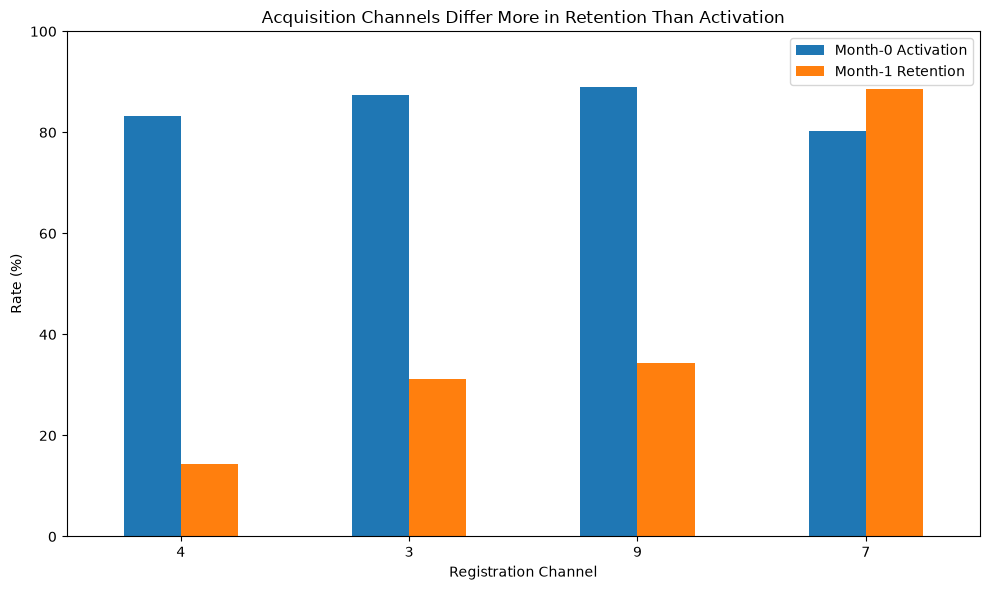

In [64]:

plot_data = (
    major_channels[
        [
            "registered_via",
            "activation_rate_pct",
            "m1_retention_pct"
        ]
    ]
    .set_index("registered_via")
)

ax = plot_data.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_title(
    "Acquisition Channels Differ More in Retention Than Activation"
)
ax.set_xlabel("Registration Channel")
ax.set_ylabel("Rate (%)")
ax.set_ylim(0, 100)

plt.xticks(rotation=0)
plt.legend(
    ["Month-0 Activation", "Month-1 Retention"]
)

plt.tight_layout()
plt.show()

### The channel story I'd actually take to a team

The major channels have fairly similar activation rates, roughly 80–89%. Their Month-1 retention is nowhere near as similar.

That means I'd be very hesitant to rank acquisition sources by signup volume or even initial activation alone. Channel 4 brings in the most users, but Channel 7's activated users behave completely differently afterward.

Without knowing the real-world meaning of the channel codes or acquisition cost, I can't say "spend more on Channel 7." I *can* say the downstream quality gap is large enough to investigate.


## 8. What I'd take away from this

### Activation is not the hard part

Across eligible cohorts, **84.0%** of registered users listen during Month 0. The much bigger problem is getting them back.

Among activated users with enough follow-up time, weighted retention falls to **25.4% at M1**, **13.3% at M3**, **11.8% at M6**, and **11.2% at M12**.

If I were using this analysis to decide where to focus, the first post-activation month would be the obvious place to start.


### Early engagement is the clearest behavioral signal I found

The normalized Month-0 engagement bands separate future retention dramatically: M1 retention ranges from **5.9%** in the lowest-engagement group to **80.6%** in the highest.

And the gap doesn't vanish after one month. At M12, those groups are still at **2.3% versus 35.0%**.

I wouldn't turn that into "make users listen every day." The analysis doesn't establish causality. But I would use early activity depth as a strong signal for lifecycle segmentation and then test onboarding or re-engagement interventions within those segments.


### Acquisition volume hides very different user quality

Channel 4 supplies most of the registrations but has only **14.4% M1 retention** among activated users. Channels 3 and 9 are substantially higher, and Channel 7 reaches **88.6%**.

Those gaps also line up with differences in Month-0 engagement.

The practical takeaway isn't that one coded channel is automatically "best." It's that acquisition reporting should follow users past signup and activation. I'd want channel identity, acquisition cost, and campaign metadata before making an actual budget decision.


## 9. What this analysis can't tell me

This is observational data. The strongest result in the notebook — the relationship between early engagement and later retention — does **not** prove that increasing someone's listening frequency would cause the same increase in retention.

Monthly cohorts also create some awkward boundaries. I adjusted Month-0 engagement for the number of days available after registration, but the underlying activity is still summarized by calendar month.

The transaction analysis has a bigger limitation: only a minority of activated users have an early observed transaction, and that subgroup retains at a dramatically higher rate than the full population. I treat those results as subgroup findings, not population estimates.

Finally, `registered_via` is only a code. Without knowing what the channels actually are, what they cost, or how targeting differed, I can compare downstream behavior but not make a complete acquisition-budget recommendation.

Those are the next pieces I'd want before moving from this analysis to an actual retention or acquisition experiment.
